# EDA

## 1. Structure

train: (10310, 132)  test: (3600, 131)
nulls:
	train: 0  test: 0


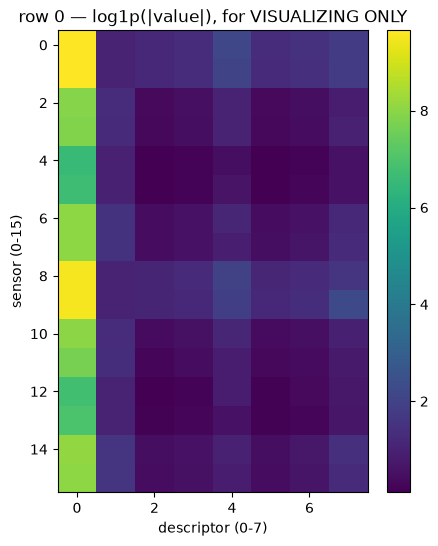

In [1]:
import sys
sys.path.insert(0, "../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import data as d

train = pd.read_csv(d.DATA_DIR / "train.csv")
test  = pd.read_csv(d.DATA_DIR / "test.csv")

print("train:", train.shape, " test:", test.shape)
print("nulls:\n\ttrain:", train.isna().sum().sum(), " test:", test.isna().sum().sum())

# visualize one row reshaped to 16 sensors x 8 descriptors
row0 = train.loc[0, d.FEATURE_COLS].to_numpy(float).reshape(d.N_SENSORS, d.N_DESCRIPTORS)
fig, ax = plt.subplots(figsize=(5, 6))
im = ax.imshow(np.log1p(np.abs(row0)), aspect="auto", cmap="viridis") # log scale for a pic
ax.set_xlabel("descriptor (0-7)"); ax.set_ylabel("sensor (0-15)")
ax.set_title("row 0 — log1p(|value|), for VISUALIZING ONLY")
plt.colorbar(im, ax=ax)

Analyse what a single row reads. the each sensor and descriptor laid out in a heatmap. Descriptor 0 scales larger relative to other descriptor readings.

## 2. Target distribution

Text(0.5, 1.0, 'class present in batch (green = yes)')

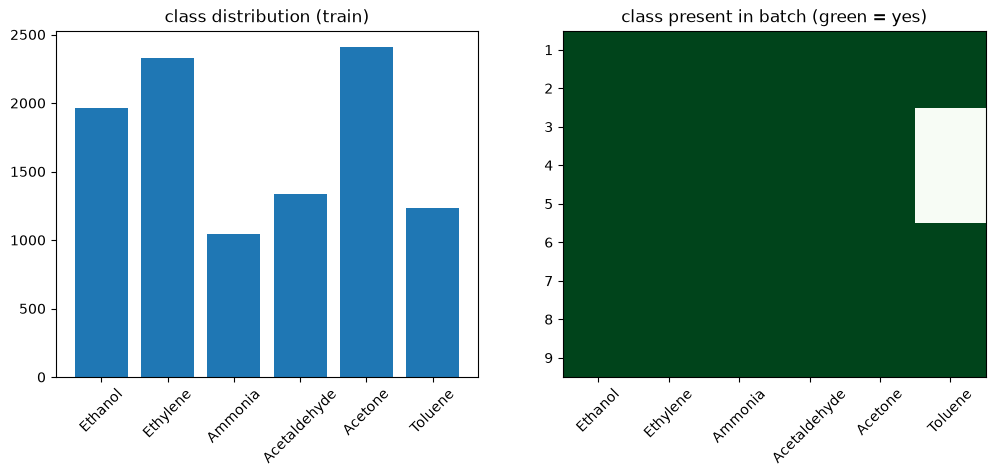

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

counts = train[d.TARGET_COL].value_counts().sort_index()
axes[0].bar([d.CLASS_NAMES[c] for c in counts.index], counts.values)
axes[0].set_title("class distribution (train)"); axes[0].tick_params(axis="x", rotation=45)

presence = pd.crosstab(train[d.BATCH_COL], train[d.TARGET_COL]).reindex(columns=range(1, 7), fill_value=0)
axes[1].imshow(presence.values > 0, cmap="Greens", aspect="auto")
axes[1].set_xticks(range(6)); axes[1].set_xticklabels([d.CLASS_NAMES[c] for c in range(1, 7)], rotation=45)
axes[1].set_yticks(range(len(presence))); axes[1].set_yticklabels(presence.index)
axes[1].set_title("class present in batch (green = yes)")

Imbalance in numbers, Accetone highest at 2409, Ammonia lowest at 1041.

batches 3,4,5 have no Toluene

## 3.  Drift Analysis Across 16 Sensors

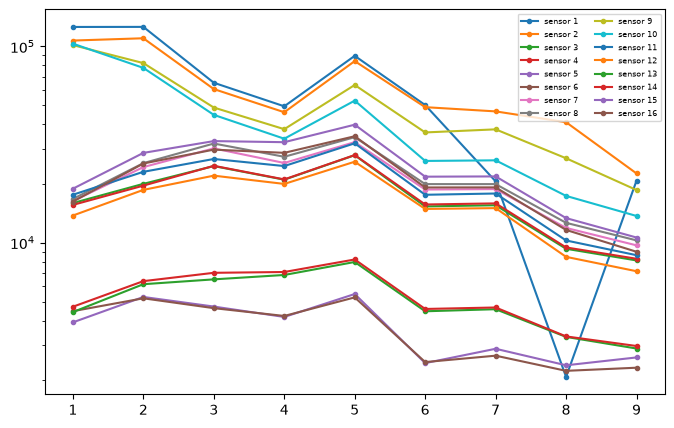

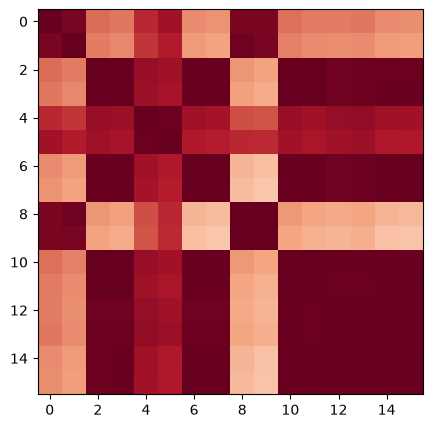

In [3]:
sensor_cols = [f"feat_{i*8+1}" for i in range(16)]   # descriptor-0, all 16 sensors
batch_means = train.groupby(d.BATCH_COL)[sensor_cols].apply(lambda g: g.abs().mean())

fig, ax = plt.subplots(figsize=(8,5))
for i, col in enumerate(sensor_cols):
    ax.plot(batch_means.index, batch_means[col], marker="o", markersize=3, label=f"sensor {i+1}")
ax.set_yscale("log")   # 3 orders of magnitude spread — linear would flatten everything into one blob
ax.legend(ncol=2, fontsize=6)

corr = batch_means.corr()   # do sensors' trajectories move together, or independently?
fig, ax = plt.subplots(figsize=(6,5))
ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

From the correlation matrix of sensors, the 16 sensors aren't independent things. Every single odd/even pair moves together almost perfectly.

Beyond pairing, there's a two-cluster split: sensors 1, 2, 9, 10 sit apart from the other 12, which are all near-perfectly correlated with each other despite sitting at different magnitude tiers. 
    Hypothesis: Sensors 1, 2, 9, 10 differ physically (different model/placement) from the other 12, which would explain both their weaker correlation with the big cluster and their more erratic drift ratios.

Batch 8's sensor 1 collapses for 90% of its rows (below 5,000, versus a normal 10k–20k median), isolated to sensor 1 alone, since its paired sensor 2 and the other big-cluster sensors read normally in the same batch.
    assuming the sensor-1 collapse is a temporary hardware fault, not a data export bug, based on it being isolated to one sensor and self-resolving by the next batch.

There is an observable split, 3 visual bands/ {1,2,9,10} the top band, and everything else. The split between the middle and bottom bands is just a baseline sensitivity thing (assumed). While the top band and the rest is a behavioural split.


## 4. Concetration Analysis

batch mean concentration vs mean magnitude correlation: 0.9485077849177623


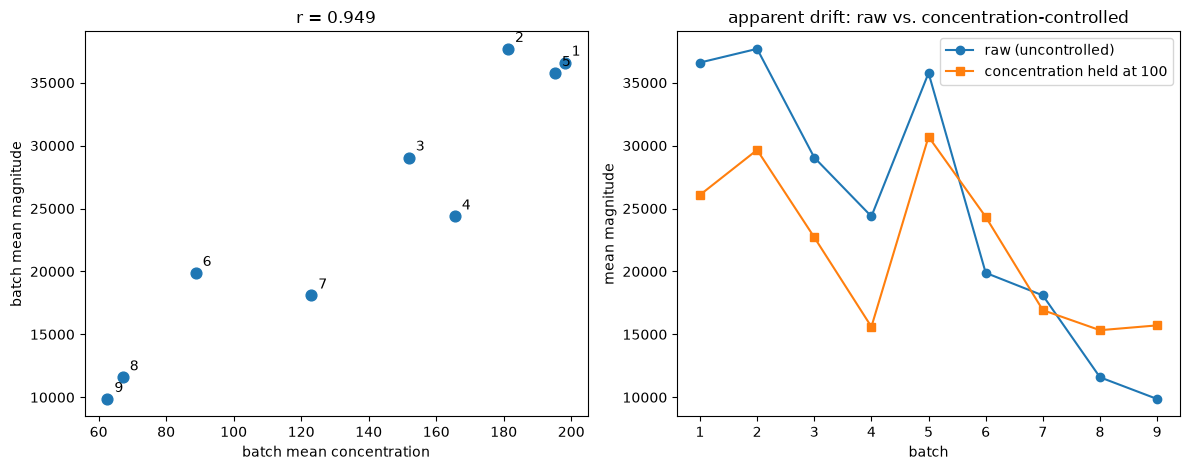

In [10]:
batch_stats = train.groupby(d.BATCH_COL)[["concentration"] + sensor_cols].apply(
    lambda g: pd.Series({
        "mean_conc": g["concentration"].mean(),
        "mean_magnitude": g[sensor_cols].abs().mean(axis=1).mean(),
    }),
    include_groups=False,
)
print("batch mean concentration vs mean magnitude correlation:",
      batch_stats["mean_conc"].corr(batch_stats["mean_magnitude"]))

fixed = train[train["concentration"] == 100]
fixed_stats = fixed.groupby(d.BATCH_COL)[sensor_cols].apply(lambda g: g.abs().mean(axis=1).mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].scatter(batch_stats["mean_conc"], batch_stats["mean_magnitude"], s=60)
for b, row in batch_stats.iterrows():
    axes[0].annotate(str(b), (row["mean_conc"], row["mean_magnitude"]), xytext=(5, 5), textcoords="offset points")
axes[0].set_xlabel("batch mean concentration"); axes[0].set_ylabel("batch mean magnitude")
axes[0].set_title(f'r = {batch_stats["mean_conc"].corr(batch_stats["mean_magnitude"]):.3f}')

axes[1].plot(batch_stats.index, batch_stats["mean_magnitude"], marker="o", label="raw (uncontrolled)")
axes[1].plot(fixed_stats.index, fixed_stats.values, marker="s", label="concentration held at 100")
axes[1].set_xlabel("batch"); axes[1].set_ylabel("mean magnitude")
axes[1].set_title("apparent drift: raw vs. concentration-controlled")
axes[1].legend()
plt.tight_layout()

COmparisons at a fixed concentration shows a real drift.
There is a downward trent, batch 1 to batch 9 drops from 26k to 16k. 

Batch 8 sensor 1 defect isn't explained by this. So concentration isnt the explanation to that.

Lower concentrations on average on the later end of the test plays some part in the drift. 

Concetration alone cant explain the varying magnitude ratios between sensors. Possibly other factors that aren't included in the dataset.

## 5. Is Batch 10 Following the Trend?

concentration — min / median / max
  batch 7         : 1.0 / 110.0 / 300.0
  batch 9         : 10.0 / 100.0 / 120.0
  batch 10 (test) : 1.0 / 150.0 / 1000.0
  all train       : 1.0 / 100.0 / 1000.0

batch 10 rows outside the training concentration range: 0

mean sensor magnitude (descriptor-0) per batch:
  batch 7         : 18092.9
  batch 9         : 9863.0
  batch 10 (test) : 19779.5


Text(0.5, 1.0, 'mean sensor magnitude (descriptor-0)')

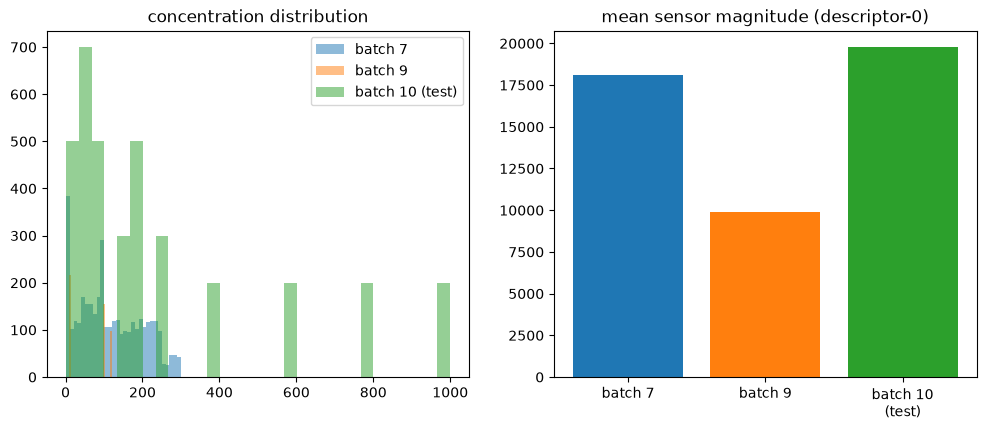

In [4]:
b7 = train[train[d.BATCH_COL] == 7]
b9 = train[train[d.BATCH_COL] == 9]
sensor_cols = [f"feat_{i*8+1}" for i in range(16)]

print("concentration — min / median / max")
for name, sub in [("batch 7", b7), ("batch 9", b9), ("batch 10 (test)", test), ("all train", train)]:
    c = sub["concentration"]
    print(f"  {name:16s}: {c.min():.1f} / {c.median():.1f} / {c.max():.1f}")

print("\nbatch 10 rows outside the training concentration range:",
      ((test.concentration < train.concentration.min()) | (test.concentration > train.concentration.max())).sum())

print("\nmean sensor magnitude (descriptor-0) per batch:")
for name, sub in [("batch 7", b7), ("batch 9", b9), ("batch 10 (test)", test)]:
    print(f"  {name:16s}: {sub[sensor_cols].abs().mean(axis=1).mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, sub, color in [("batch 7", b7, "#1f77b4"), ("batch 9", b9, "#ff7f0e"), ("batch 10 (test)", test, "#2ca02c")]:
    axes[0].hist(sub["concentration"], bins=30, alpha=0.5, label=name, color=color)
axes[0].set_title("concentration distribution"); axes[0].legend()

names = ["batch 7", "batch 9", "batch 10\n(test)"]
means = [sub[sensor_cols].abs().mean(axis=1).mean() for sub in (b7, b9, test)]
axes[1].bar(names, means, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1].set_title("mean sensor magnitude (descriptor-0)")

batch 10's concentration histogram is right shifted, and its magnitude bar sits above batch 9's and roughly in level with batch 7's. So it doesn't really follow the trend of lower concentration over time.